<a href="https://colab.research.google.com/github/uday367/deep-learning/blob/main/hidden_layer_with_relu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

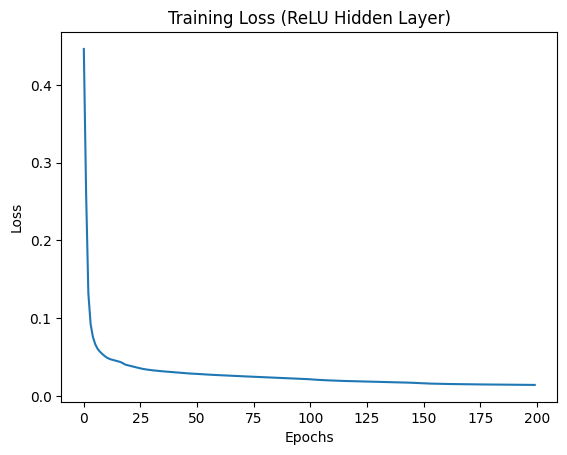

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target.reshape(-1,1)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Network structure
input_size = X_train.shape[1]
hidden_size = 10
output_size = 1
lr = 0.01
epochs = 200

# Initialize weights
np.random.seed(0)
W1 = np.random.randn(input_size, hidden_size)
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size)
b2 = np.zeros((1, output_size))

# Activation functions
def relu(x):
    return np.maximum(0,x)

def relu_derivative(x):
    return (x>0).astype(float)

def sigmoid(x):
    return 1/(1+np.exp(-x))

# Training
losses = []

for epoch in range(epochs):

    # Forward pass
    z1 = np.dot(X_train,W1) + b1
    a1 = relu(z1)

    z2 = np.dot(a1,W2) + b2
    y_pred = sigmoid(z2)

    # Loss
    loss = np.mean((y_train - y_pred)**2)
    losses.append(loss)

    # Backprop
    d_z2 = (y_pred - y_train) * y_pred * (1 - y_pred)
    d_W2 = np.dot(a1.T, d_z2)
    d_b2 = np.sum(d_z2, axis=0)

    d_a1 = np.dot(d_z2, W2.T)
    d_z1 = d_a1 * relu_derivative(z1)
    d_W1 = np.dot(X_train.T, d_z1)
    d_b1 = np.sum(d_z1, axis=0)

    # Update weights
    W1 -= lr * d_W1
    b1 -= lr * d_b1
    W2 -= lr * d_W2
    b2 -= lr * d_b2

# Plot loss graph
plt.plot(losses)
plt.title("Training Loss (ReLU Hidden Layer)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()